# Нейросетевое декодирование кода БЧХ(63, 45)
Сравнительный анализ классических алгебраических алгоритмов, графовых нейронных сетей (GNN) и гибридного Оракула.

In [15]:
import os
import warnings
import time
import numpy as np
import matplotlib.pyplot as plt

# Базовые модули алгебры и канала
from core.bch_exact import ExactBCH
from core.topology_manager import TopologyManager
from core.channel import CommunicationChannel

# Классические декодеры
from baselines.berlekamp_massey import BerlekampMasseyDecoder
from baselines.osd import OSDDecoder
from baselines.classic_bp import ClassicMinSumBP

# Нейросетевые модели
from neural.ew_gnn import EW_GNN
from neural.neural_min_sum import NeuralMinSum
from neural.oracle_system import LiveNeuralOracle

# Обучение
from training.trainer import train_neural_oracle

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

print("TensorFlow версия:", tf.__version__)
print("Доступные GPU устройства:", tf.config.list_physical_devices('GPU'))

TensorFlow версия: 2.21.0
Доступные GPU устройства: []


### 1. Параметры кода БЧХ(63, 45) и канала связи
Построение точной проверочной матрицы $H$, порождающей матрицы $G$ и анализ коротких циклов в графе Таннера.

In [16]:
bch = ExactBCH("bch_63_45")
channel = CommunicationChannel(bch.n, bch.k, G=bch.G)

num_4_cycles = TopologyManager.count_4_cycles(bch.H)

print(f"Параметры кода: n = {bch.n}, k = {bch.k}, t = {bch.t} (исправление до {bch.t} ошибок)")
print(f"Скорость кодирования (R): {bch.k / bch.n:.4f}")
print(f"Размерность матрицы H: {bch.H.shape[0]} x {bch.H.shape[1]}")
print(f"Количество 4-циклов в графе Таннера: {num_4_cycles}")

Параметры кода: n = 63, k = 45, t = 3 (исправление до 3 ошибок)
Скорость кодирования (R): 0.7143
Размерность матрицы H: 18 x 63
Количество 4-циклов в графе Таннера: 5349


### 2. Инициализация моделей декодирования
Подготовка бейзлайнов (Berlekamp-Massey, Min-Sum BP, OSD-1) и нейросетевых архитектур.

In [17]:
# Классические методы
bm_decoder = BerlekampMasseyDecoder(bch)
bp_decoder = ClassicMinSumBP(bch.H, num_iter=20)
osd_decoder = OSDDecoder(bch.G, order=1)

# Нейросетевые графовые архитектуры (8 итераций)
ew_gnn_model = EW_GNN(bch.H, num_embed_dims=20, num_hidden_units=40, num_iter=8)
nms_model = NeuralMinSum(bch.H, num_iter=8)

print("Все декодеры успешно инициализированы.")

Все декодеры успешно инициализированы.


### 3. Обучение нейросетевых декодеров
Тренировка графовых сетей на лету со случайным шумом в диапазоне 2.0–6.0 дБ и косинусным снижением скорости обучения.
Если сохраненные веса уже существуют, они будут загружены автоматически.

In [18]:
weights_gnn_file = "weights_ew_gnn.weights.h5"
weights_nms_file = "weights_nms.weights.h5"

# Обучение EW-GNN
if os.path.exists(weights_gnn_file):
    print("Загрузка сохраненных весов EW-GNN...")
    ew_gnn_model.load_weights(weights_gnn_file)
else:
    print("Обучение EW-GNN (20 000 шагов)...")
    train_neural_oracle(ew_gnn_model, channel, bch.H, epochs=20000, batch_size=256, lr_start=5e-4)
    ew_gnn_model.save_weights(weights_gnn_file)

# Обучение Neural Min-Sum
if os.path.exists(weights_nms_file):
    print("Загрузка сохраненных весов Neural Min-Sum...")
    nms_model.load_weights(weights_nms_file)
else:
    print("\nОбучение Neural Min-Sum (4 000 шагов)...")
    train_neural_oracle(nms_model, channel, bch.H, epochs=4000, batch_size=256, lr_start=1e-3)
    nms_model.save_weights(weights_nms_file)

# Инициализация Живого Оракула на базе обученной NMS и OSD-1 Fallback
oracle_system = LiveNeuralOracle(bch.H, neural_model=nms_model, fallback_decoder=osd_decoder)
print("\nОбучение завершено. Модели готовы к симуляции.")

Загрузка сохраненных весов EW-GNN...
Загрузка сохраненных весов Neural Min-Sum...

Обучение завершено. Модели готовы к симуляции.


### 4. Оценка помехоустойчивости (Монте-Карло)
Тестирование характеристик BER и FER в диапазоне $E_b/N_0$ от 2.0 до 9.0 дБ в формате вывода таблиц NVIDIA Labs.

In [19]:
def run_simulation_table(decoder_name, decode_fn, channel, snr_range, target_fer=40, batch_size=256):
    print(f"\nДекодер: {decoder_name}")
    print(f"{'Eb/N0 (dB)':>10} | {'BER':>10} | {'FER':>10} | {'Bit Err':>8} | {'Frame Err':>9} | {'Total Frames':>12}")
    print("-" * 72)

    ber_list, fer_list = [], []

    for snr in snr_range:
        bit_errors, frame_errors = 0, 0
        total_bits, total_frames = 0, 0

        if snr <= 4.0:
            max_batches = 40
        elif snr == 5.0:
            max_batches = 200
        else:
            max_batches = 100

        for _ in range(max_batches):
            llr_batch, c_batch = channel.generate_llr(batch_size, ebno_db=snr, return_c=True)
            decoded = decode_fn(llr_batch)

            b_err = int(np.sum(decoded != c_batch))
            f_err = int(np.sum(np.any(decoded != c_batch, axis=1)))

            bit_errors += b_err
            frame_errors += f_err
            total_bits += batch_size * channel.n
            total_frames += batch_size

            if frame_errors >= target_fer:
                break

        ber = bit_errors / total_bits
        fer = frame_errors / total_frames
        ber_list.append(ber)
        fer_list.append(fer)

        print(f"{snr:10.2f} | {ber:10.2e} | {fer:10.2e} | {bit_errors:8d} | {frame_errors:9d} | {total_frames:12d}")

    return ber_list, fer_list

snr_grid = np.arange(2.0, 9.5, 1.0)

def ew_gnn_wrapper(llrs):
    return (ew_gnn_model(llrs)[-1].numpy() < 0).astype(int)

def nms_wrapper(llrs):
    return (nms_model(llrs)[-1].numpy() < 0).astype(int)


def osd_optimized_wrapper(llrs):
    r = (llrs < 0).astype(np.int8)
    syn = np.dot(r, bch.H.T) % 2
    clean_mask = (np.sum(syn, axis=1) == 0)

    if np.all(clean_mask):
        return r

    decoded = np.copy(r)
    err_idx = np.where(~clean_mask)[0]
    decoded[err_idx] = osd_decoder.decode(llrs[err_idx])
    return decoded

results_ber = {}
results_fer = {}

decoders_suite = [
    ("Berlekamp-Massey (Hard)", bm_decoder.decode),
    ("Classic Min-Sum (20 it)", bp_decoder.decode),
    ("EW-GNN (8 it, NVIDIA)", ew_gnn_wrapper),
    ("Neural Min-Sum (8 it)", nms_wrapper),
    ("Live Neural Oracle", oracle_system.decode),
    ("OSD-1 (ML Bound)", osd_optimized_wrapper)
]

for name, fn in decoders_suite:
    ber, fer = run_simulation_table(name, fn, channel, snr_grid, target_fer=40)
    results_ber[name] = ber
    results_fer[name] = fer

oracle_system.print_diagnostics()


Декодер: Berlekamp-Massey (Hard)
Eb/N0 (dB) |        BER |        FER |  Bit Err | Frame Err | Total Frames
------------------------------------------------------------------------
      2.00 |   6.61e-02 |   6.37e-01 |     1066 |       163 |          256
      3.00 |   2.87e-02 |   3.09e-01 |      463 |        79 |          256
      4.00 |   8.62e-03 |   9.38e-02 |      278 |        48 |          512
      5.00 |   2.02e-03 |   2.40e-02 |      228 |        43 |         1792
      6.00 |   1.68e-04 |   2.08e-03 |      203 |        40 |        19200
      7.00 |   5.58e-06 |   7.81e-05 |        9 |         2 |        25600
      8.00 |   0.00e+00 |   0.00e+00 |        0 |         0 |        25600
      9.00 |   0.00e+00 |   0.00e+00 |        0 |         0 |        25600

Декодер: Classic Min-Sum (20 it)
Eb/N0 (dB) |        BER |        FER |  Bit Err | Frame Err | Total Frames
------------------------------------------------------------------------
      2.00 |   6.23e-02 |   6.56e-01

### 5. Итоговые кривые помехоустойчивости
Построение графиков вероятности битовой ошибки (BER) и блоковой ошибки (FER) в академическом стиле IEEE.

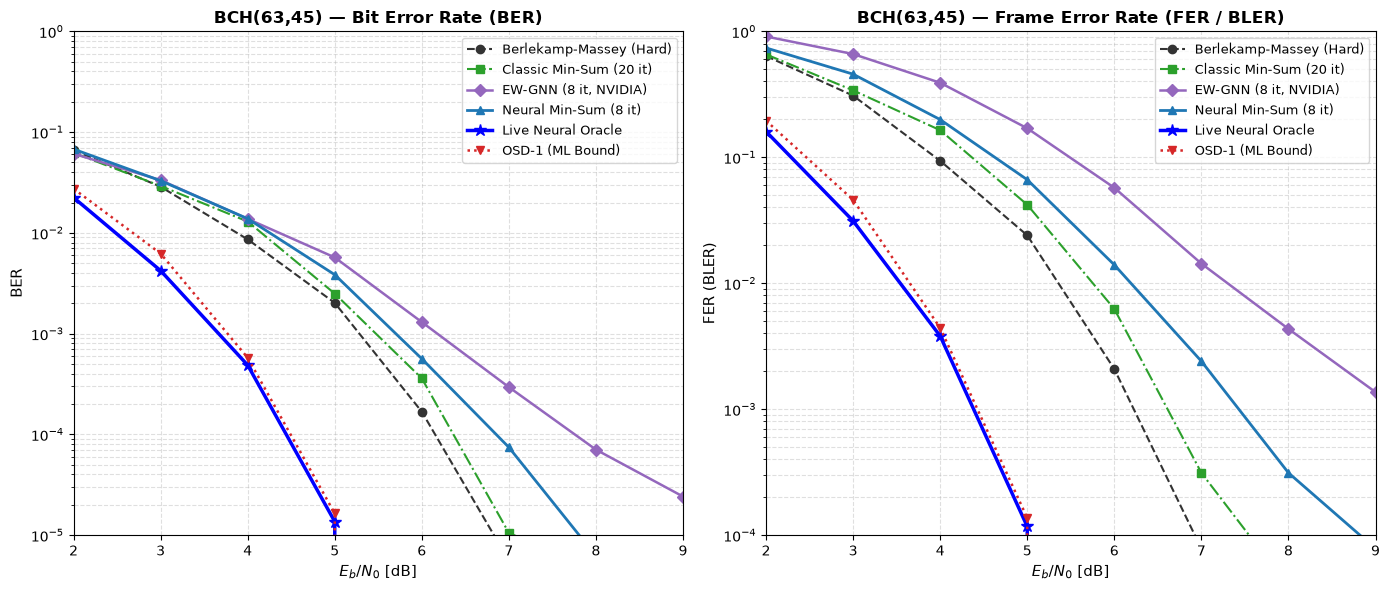

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

styles = {
    'Berlekamp-Massey (Hard)': {'color': '#333333', 'marker': 'o', 'linestyle': '--', 'linewidth': 1.5},
    'Classic Min-Sum (20 it)': {'color': '#2ca02c', 'marker': 's', 'linestyle': '-.', 'linewidth': 1.5},
    'EW-GNN (8 it, NVIDIA)':   {'color': '#9467bd', 'marker': 'D', 'linestyle': '-', 'linewidth': 1.8},
    'Neural Min-Sum (8 it)':   {'color': '#1f77b4', 'marker': '^', 'linestyle': '-', 'linewidth': 2.0},
    'Live Neural Oracle':      {'color': '#0000ff', 'marker': '*', 'linestyle': '-', 'linewidth': 2.5, 'markersize': 9},
    'OSD-1 (ML Bound)':        {'color': '#d62728', 'marker': 'v', 'linestyle': ':', 'linewidth': 1.8}
}

# График BER
ax_ber = axes[0]
for name, ber_vals in results_ber.items():
    st = styles.get(name, {'marker': 'x'})
    ax_ber.semilogy(snr_grid, ber_vals, label=name, **st)

ax_ber.set_title('BCH(63,45) — Bit Error Rate (BER)', fontsize=12, fontweight='bold')
ax_ber.set_xlabel('$E_b/N_0$ [dB]', fontsize=11)
ax_ber.set_ylabel('BER', fontsize=11)
ax_ber.grid(True, which='both', linestyle='--', alpha=0.4)
ax_ber.set_ylim([1e-5, 1.0])
ax_ber.set_xlim([2.0, 9.0])
ax_ber.legend(fontsize=9, loc='upper right')

# График FER
ax_fer = axes[1]
for name, fer_vals in results_fer.items():
    st = styles.get(name, {'marker': 'x'})
    ax_fer.semilogy(snr_grid, fer_vals, label=name, **st)

ax_fer.set_title('BCH(63,45) — Frame Error Rate (FER / BLER)', fontsize=12, fontweight='bold')
ax_fer.set_xlabel('$E_b/N_0$ [dB]', fontsize=11)
ax_fer.set_ylabel('FER (BLER)', fontsize=11)
ax_fer.grid(True, which='both', linestyle='--', alpha=0.4)
ax_fer.set_ylim([1e-4, 1.0])
ax_fer.set_xlim([2.0, 9.0])
ax_fer.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=300)
plt.show()